# 00 - Setup

In [1]:
import os
import stampede as st
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from pydeseq2.ds import DeseqStats
from pydeseq2.dds import DeseqDataSet

In [2]:
# dictionary with input files per slide
slides = {
    1: {
        "exprmat": "exprMat_file.csv.gz",
        "metadata": "metadata_file.csv.gz",
        "fov_positions": "fov_positions_file.csv.gz",
    }
}
# optional filepath prefix
data_dir = "data"

In [3]:
os.makedirs(st.config["adata_dir"], exist_ok=True)

# 01 - Read

In [4]:
# table mapping the FOVs per slide to each sample
# column "fovs" accepts any combination of comma separated values (e.g. 1,2,3) and ranges (e.g. 4-6)
samples_df = pd.read_table("data/sample2fov.csv", sep=",")
st.validate_input(slides, samples_df, data_dir)
samples_df

,sample,fovs,slide
0,s1,10-18,1
1,s2,19-27,1
2,s3,28-36,1


In [5]:
# combine the input files into a single cell object and write it to file
adata_file = os.path.join(st.config["adata_dir"], "raw_data.h5ad")
st.read_cosmx(
    slides,
    samples_df,
    adata_file,
    data_dir=data_dir,
    overwrite=False,
    verbose=True,
)

Slide 1/1 starting...
50_000 rows parsed
100_000 rows parsed
Slide 1/1 done!



'adatas/raw_data.h5ad'

In [6]:
adata = sc.read_h5ad(adata_file)
adata.obs

,fov,cell_ID,slide,slide-fov,Area,AspectRatio,CenterX_local_px,CenterY_local_px,Width,Height,...,nCount,nCountPerCell,nFeaturePerCell,propNegativeCellAvg,complexityCellAvg,errorCtPerCellEstimate,percOfDataFromErrorPerCell,qcFlagsFOV,sample,fovs
slide-fov-cell_ID,,,,,,,,,,,,,,,,,,,,,
1-10-1,10,1,1,1-10,4260,0.97,2902,613,77,75,...,140803,863.822086,670.730061,0.000315,1.245668,87.131902,0.100868,Pass,s1,10-18
1-10-2,10,2,1,1-10,5228,0.95,3007,623,83,87,...,140803,863.822086,670.730061,0.000315,1.245668,87.131902,0.100868,Pass,s1,10-18
1-10-3,10,3,1,1-10,3204,0.89,2947,649,71,63,...,140803,863.822086,670.730061,0.000315,1.245668,87.131902,0.100868,Pass,s1,10-18
1-10-4,10,4,1,1-10,22940,0.81,2833,746,191,237,...,140803,863.822086,670.730061,0.000315,1.245668,87.131902,0.100868,Pass,s1,10-18
1-10-5,10,5,1,1-10,4404,0.76,2990,691,93,71,...,140803,863.822086,670.730061,0.000315,1.245668,87.131902,0.100868,Pass,s1,10-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1-36-271,36,271,1,1-36,4264,0.88,1812,2281,81,71,...,110510,401.854545,338.160000,0.000438,1.168196,46.031818,0.114548,Pass,s3,28-36
1-36-272,36,272,1,1-36,5024,0.79,397,3328,87,69,...,110510,401.854545,338.160000,0.000438,1.168196,46.031818,0.114548,Pass,s3,28-36
1-36-273,36,273,1,1-36,5460,0.98,323,3370,83,81,...,110510,401.854545,338.160000,0.000438,1.168196,46.031818,0.114548,Pass,s3,28-36


# 02 - QC

## 02a - Slide QC

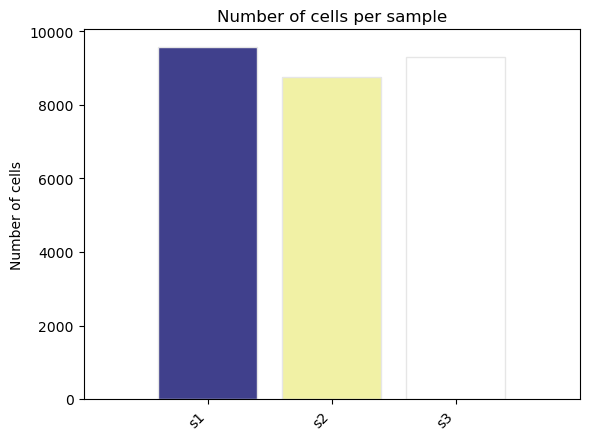

In [7]:
fig, ax = st.pl.ncell_per_condition(adata, "sample")
plt.show()

In [8]:
st.pp.slide_qc(adata, slides, ["sample"], data_dir=data_dir)
adata.uns["fov_metadata"].head()

,slide-fov,slide,fov,x,y,nCounts,nCell,mean_CountsPerCell,nCount_negprobes,mean_NegProbe-CountsPerCell,nCount_falsecode,mean_FalseCode-CountsPerCell,mean_CellSize,Failed_AtoMX_QC,sample
0,1-10,1,10,19773,149405,140803,163,863.822086,46,0.282209,480,2.944785,63.957736,0,s1
1,1-11,1,11,24029,149405,752088,848,886.896226,274,0.323113,2569,3.029481,54.344592,0,s1
2,1-12,1,12,28285,149405,50213,47,1068.361702,21,0.446809,151,3.212766,74.681880,0,s1
3,1-13,1,13,19773,145149,1241593,1866,665.376742,521,0.279207,5842,3.130761,52.223075,0,s1
4,1-14,1,14,24029,145149,2638265,3391,778.019758,916,0.270127,10325,3.044825,52.564838,0,s1


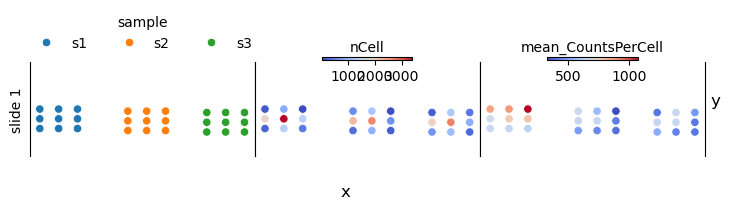

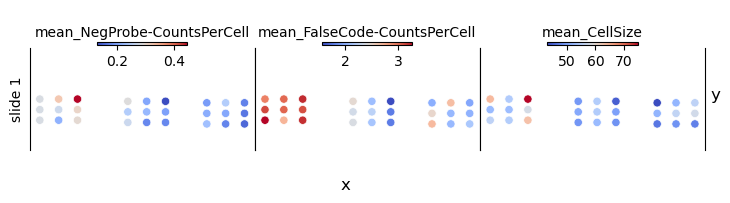

In [9]:
# this dataset was subset from a much larger slide
# the plot limits in this tutorial are extended to provide a sense of scale
fig, axs = st.pl.slide_qc(
    adata, columns=["sample", "nCell", "mean_CountsPerCell"], figsize=(2.5, 0.5), legend_kwargs={"ncols": 3}
)
ylim = axs[1, 0].get_ylim()
axs[1, 0].set_ylim(ylim[0]-10_000, ylim[1]+20_000)
plt.show()

fig, axs = st.pl.slide_qc(
    adata, columns=["mean_NegProbe-CountsPerCell", "mean_FalseCode-CountsPerCell", "mean_CellSize"], figsize=(2.5, 0.5)
)
ylim = axs[1, 0].get_ylim()
axs[1, 0].set_ylim(ylim[0]-10_000, ylim[1]+20_000)
plt.show()

### Visualizing Field of View edge-effects

Cells on the edges of an Field of View (FOV) may have been truncated.
Furthermore, we tend to detect less RNA in them.
There may also be a bias to the corners and/or one or two edges in the dataset.


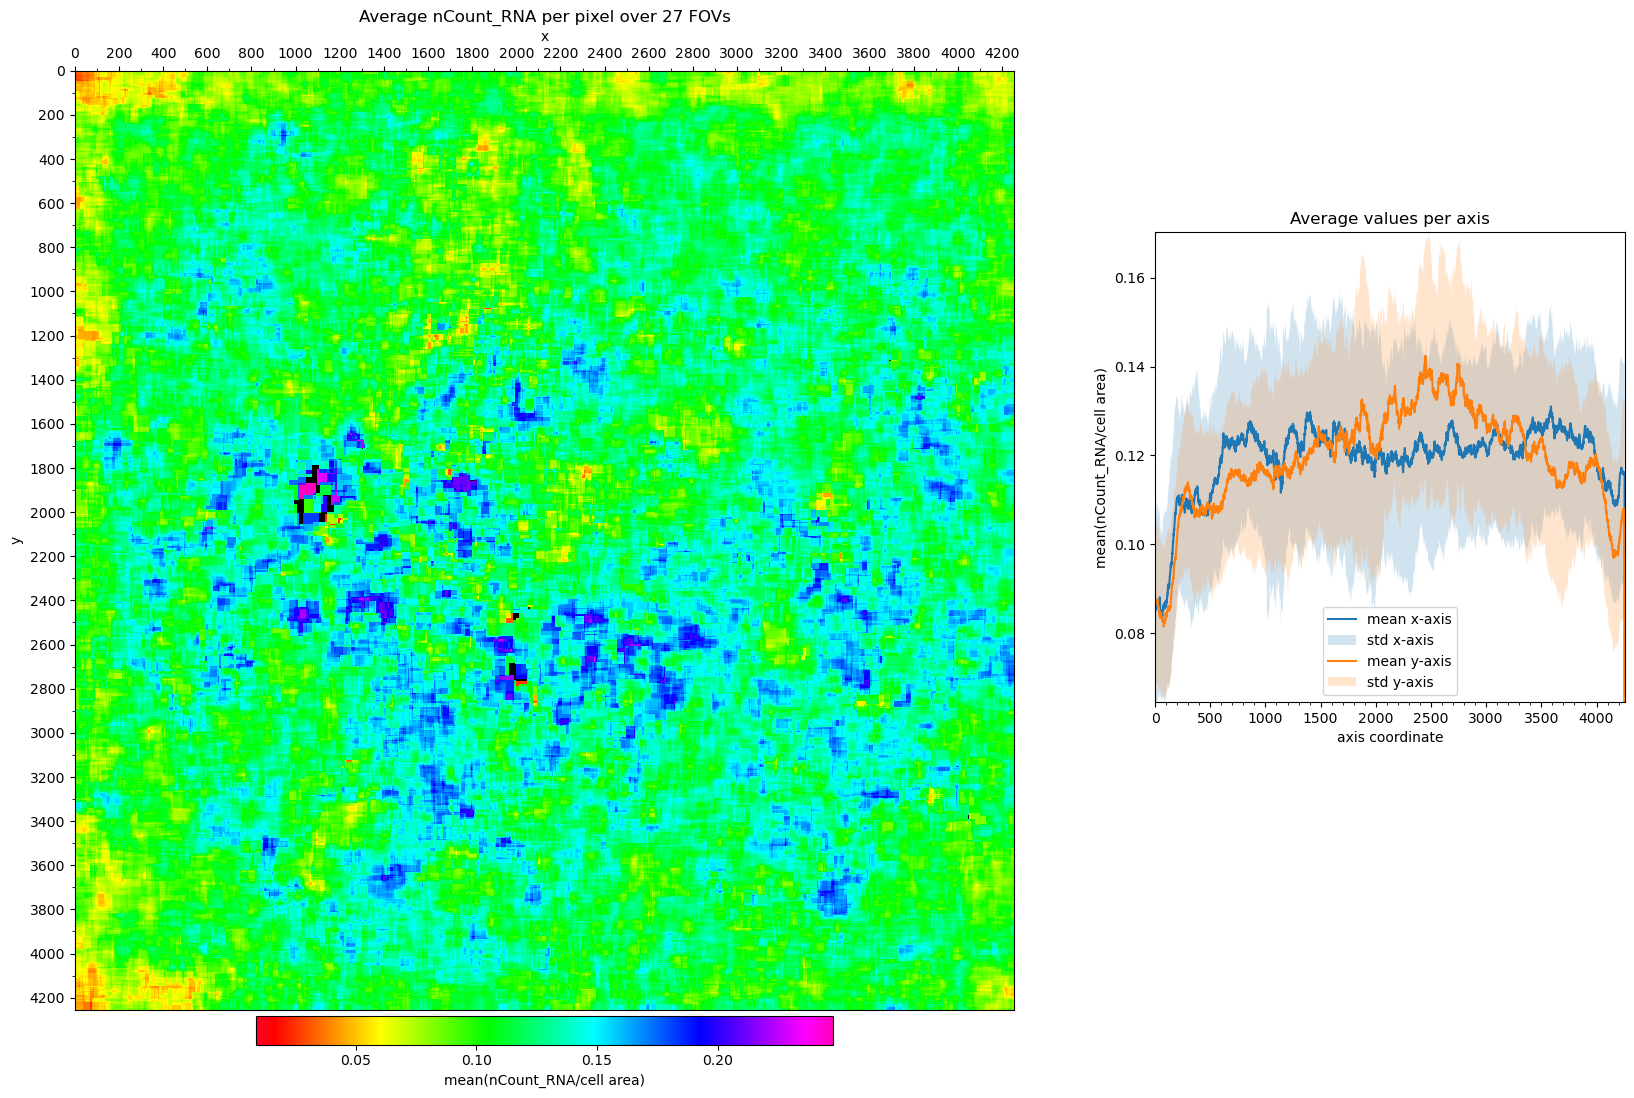

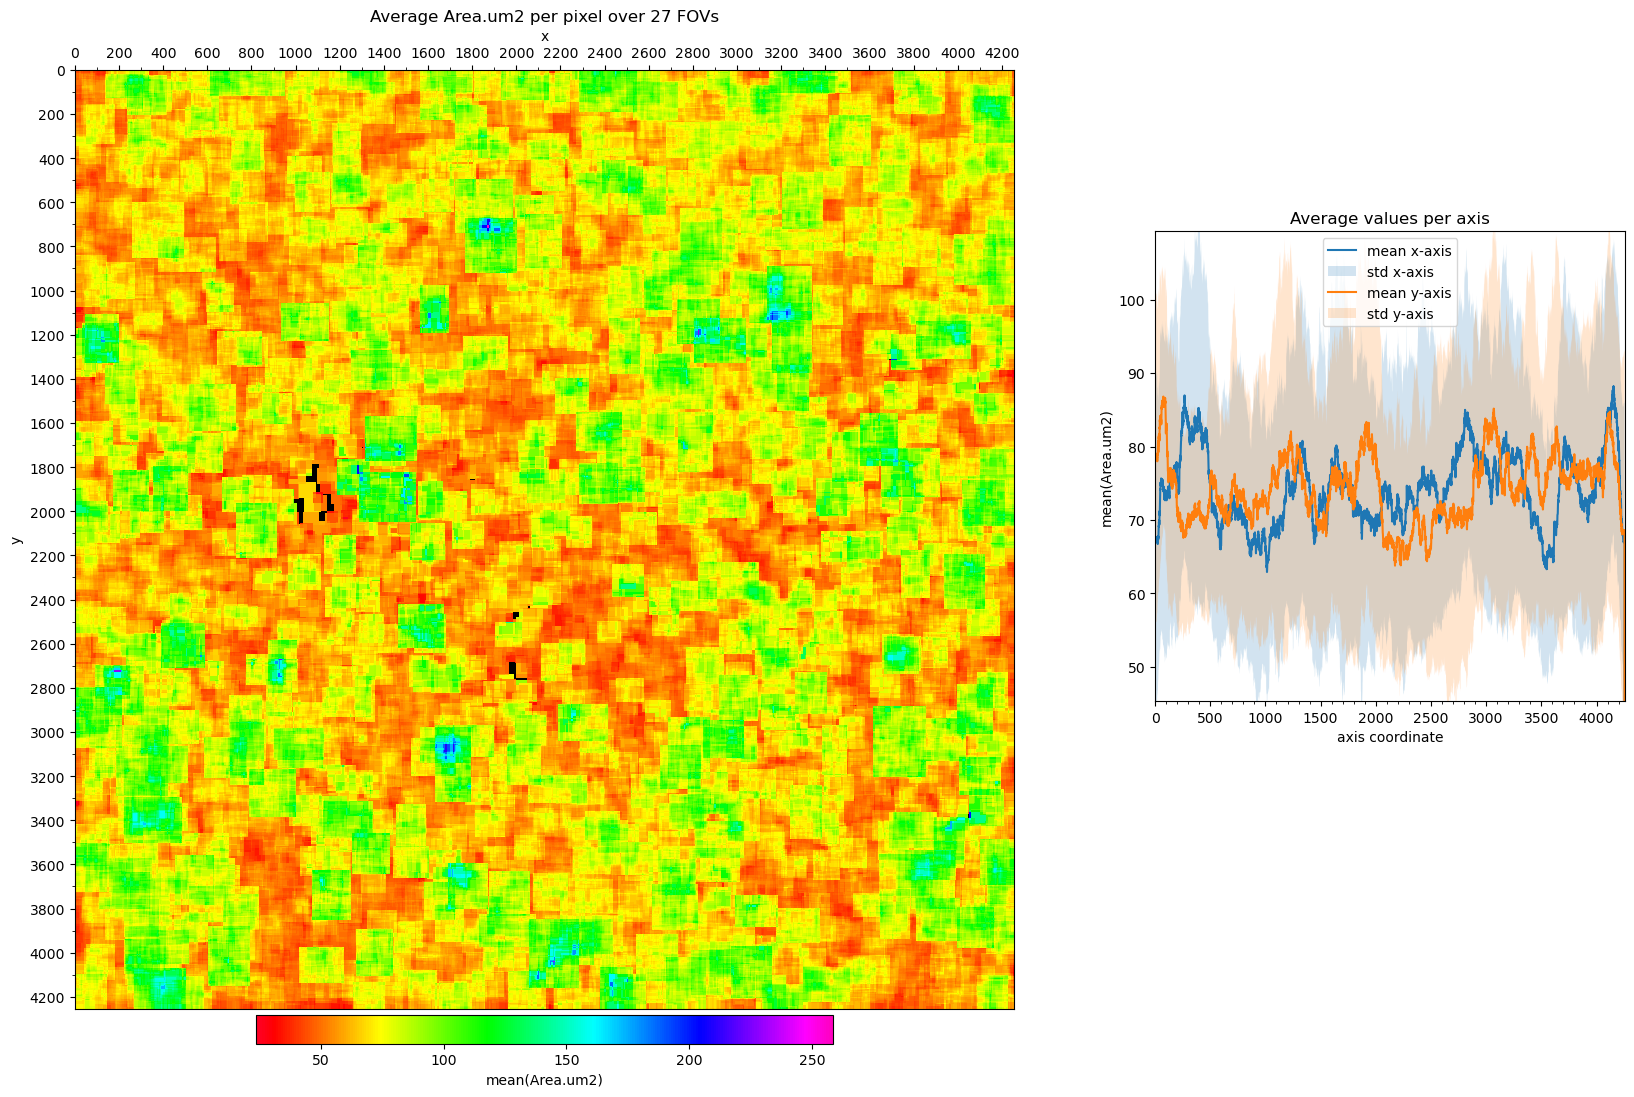

In [10]:
# plot the average nCount_RNA per pixel over all FOVs
fig, axs = st.pl.avg_per_pixel(
    adata, column='nCount_RNA', normalize_cell_area=True
)
plt.show()

# plot the cell area for all FOVs. 
# (do not normalize for cell area when plotting the cell area)
fig, axs = st.pl.avg_per_pixel(
    adata, column='Area.um2', normalize_cell_area=False
)
plt.show()

dist2edge_threshold=50


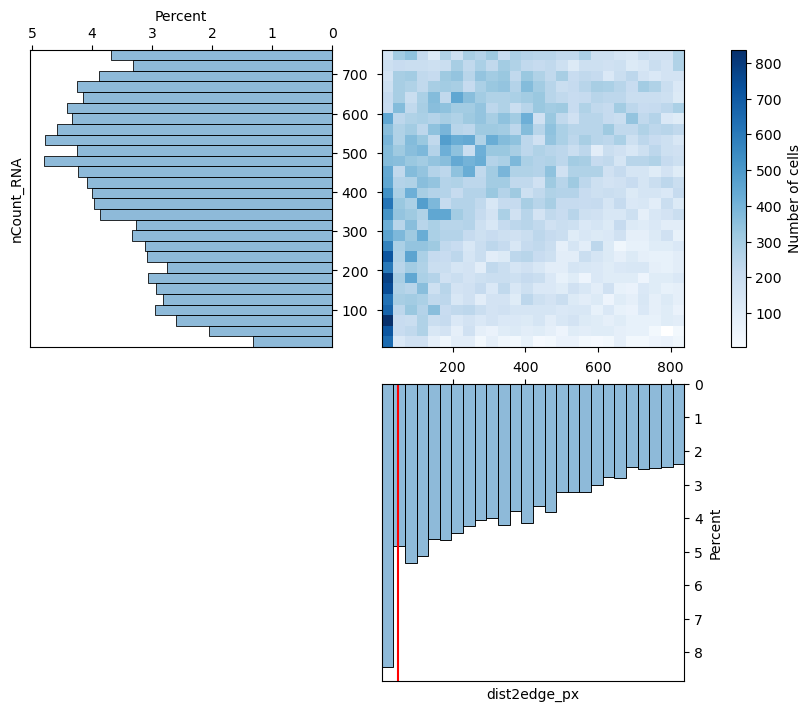

In [11]:
# visualize the effect of removing cells based on distance to FOV edge
fig, axs = st.pl.correlations(adata, xcolumn="dist2edge_px", ycolumn="nCount_RNA", max_quantile=0.7)

dist2edge_threshold = 50
print(f"{dist2edge_threshold=}")
axs[1, 1].axvline(dist2edge_threshold, color="red")
plt.show()

In [12]:
adata = st.pp.filter_edges(adata, dist2edge_threshold)

1_729 cells filtered out, 25_896 cells remaining.


## 02b - gene QC

In [13]:
# remove non-PBMC genes
fname = os.path.join(data_dir, "blacklist_pbmc.txt")
blacklist = pd.read_table(fname, header=None)[0].to_list()

before = len(adata.var)
adata = adata[:, ~adata.var.index.isin(blacklist)].copy()
after = len(adata.var)
print(before - after, "genes filtered out")

902 genes filtered out


In [14]:
# mark core immune genes
fname = os.path.join(data_dir, "core_immune_genes_pbmc.txt")
whitelist = pd.read_table(fname, header=None)[0].to_list()
adata.var["is_core_immune_gene"] = adata.var.index.isin(whitelist)

In [15]:
# determine a noise threshold for gene expression using the mean expression 
# and standard deviation of the negative control probes
st.pp.gene_qc(adata)
adata.var

,is_core_immune_gene,is_negctrl,is_sysctrl,nCell,pctCell,nTranscript,mean_Transcript,above_noise
A1BG,False,False,False,5625,21.72,6883,0.265794,True
A2M,True,False,False,635,2.45,658,0.025409,True
AAAS,False,False,False,1416,5.47,1496,0.057770,True
AAK1,True,False,False,2175,8.40,2363,0.091250,True
AAMP,False,False,False,1483,5.73,1591,0.061438,True
...,...,...,...,...,...,...,...,...
ZSWIM6,True,False,False,854,3.30,888,0.034291,True
ZWINT,True,False,False,969,3.74,1019,0.039350,True
ZYG11B,False,False,False,1855,7.16,2002,0.077309,True
ZYX,True,False,False,2650,10.23,3012,0.116311,True


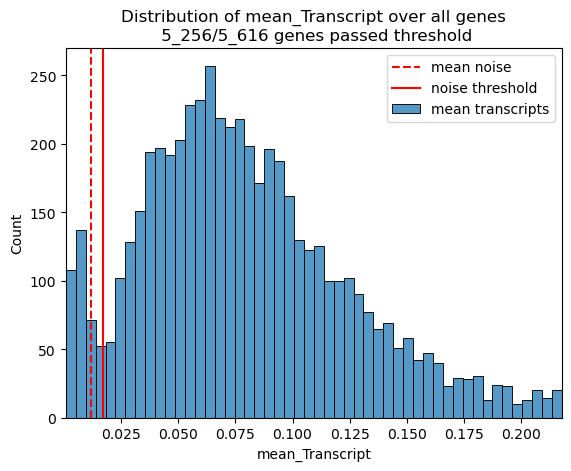

In [16]:
fig, ax = st.pl.noise_threshold(adata, max_quantile=0.95)
plt.show()

In [17]:
adata = st.pp.filter_genes(adata)

377 genes filtered out, 5_239 genes remaining.


## 02c - cell QC

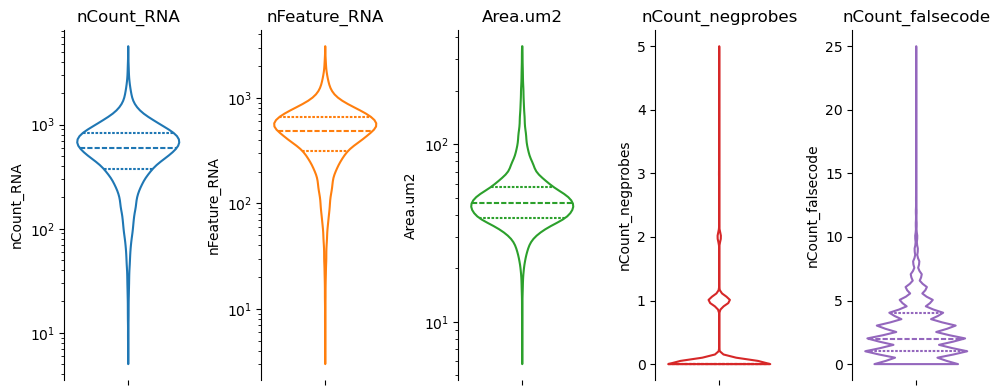

In [18]:
fig, axs = st.pl.violin(
    adata, 
    ["nCount_RNA", "nFeature_RNA", "Area.um2", "nCount_negprobes", "nCount_falsecode"],
    log_scale=(True, True, True, False, False)
)
plt.show()

In [19]:
adata = st.pp.filter_cells(
    adata, 
    falsecode_max = 4,
    negprobe_max = 2,
    ntranscript_min = 250,
    ntranscript_max = 1500,
    area_min = 25,
    area_max = 110,
)

8_690 cells filtered out, 17_206 cells remaining.


In [20]:
st.pp.gene_qc_postfilter(adata)
adata.var[["nCell", "nCell_postfilter", "pctCell", "pctCell_postfilter"]]

,nCell,nCell_postfilter,pctCell,pctCell_postfilter
A1BG,5625,3773,21.72,21.93
A2M,635,427,2.45,2.48
AAAS,1416,980,5.47,5.70
AAK1,2175,1476,8.40,8.58
AAMP,1483,965,5.73,5.61
...,...,...,...,...
ZSWIM6,854,565,3.30,3.28
ZWINT,969,626,3.74,3.64
ZYG11B,1855,1226,7.16,7.13
ZYX,2650,1811,10.23,10.53


In [21]:
st.pp.cell_qc_postfilter(adata)
adata.obs[["nFeature_RNA", "nFeature_RNA_postfilter", "nCount_RNA", "nCount_RNA_postfilter"]]

,nFeature_RNA,nFeature_RNA_postfilter,nCount_RNA,nCount_RNA_postfilter
slide-fov-cell_ID,,,,
1-10-1,627,560,821,748
1-10-2,873,771,1185,1067
1-10-5,961,843,1214,1087
1-10-6,648,573,838,748
1-10-8,831,716,1015,888
...,...,...,...,...
1-36-269,750,643,900,786
1-36-270,725,629,863,754
1-36-272,847,718,1033,894


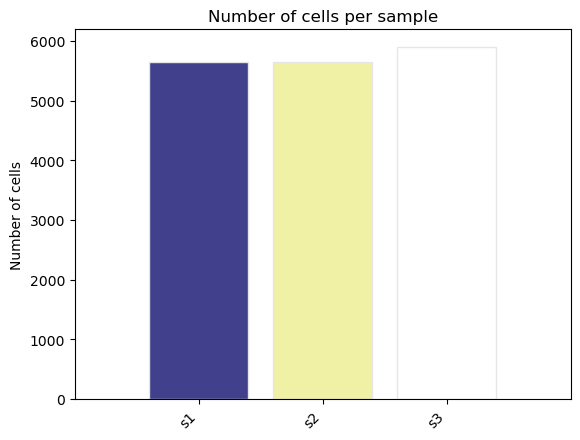

In [22]:
fig, ax = st.pl.ncell_per_condition(adata, columns = ["sample"])
plt.show()

# 03 - Dimensionality reduction

In [23]:
st.pp.binarize(adata)

binary layer set as adata.X


/home/siebrenf/git/stampede/stampede/_dim_red.py:63: UserWarning: Due to subsetting on is_core_immune_gene, the lowest number of counts in a cell is 47 transcripts. (167 transcripts before subsetting). Consider if you need to refilter cells based on the total count within the is_core_immune_gene mask.

  warnings.warn(


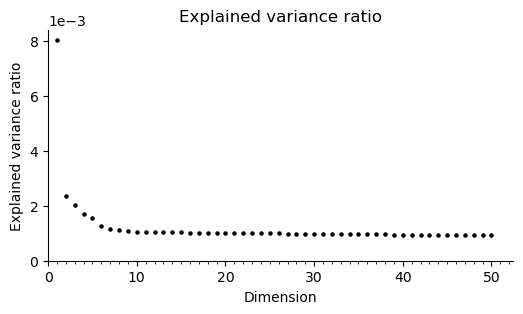

In [24]:
st.pp.dim_red(adata, use_genes="is_core_immune_gene")
fig, ax = st.pl.scree(adata)
plt.show()

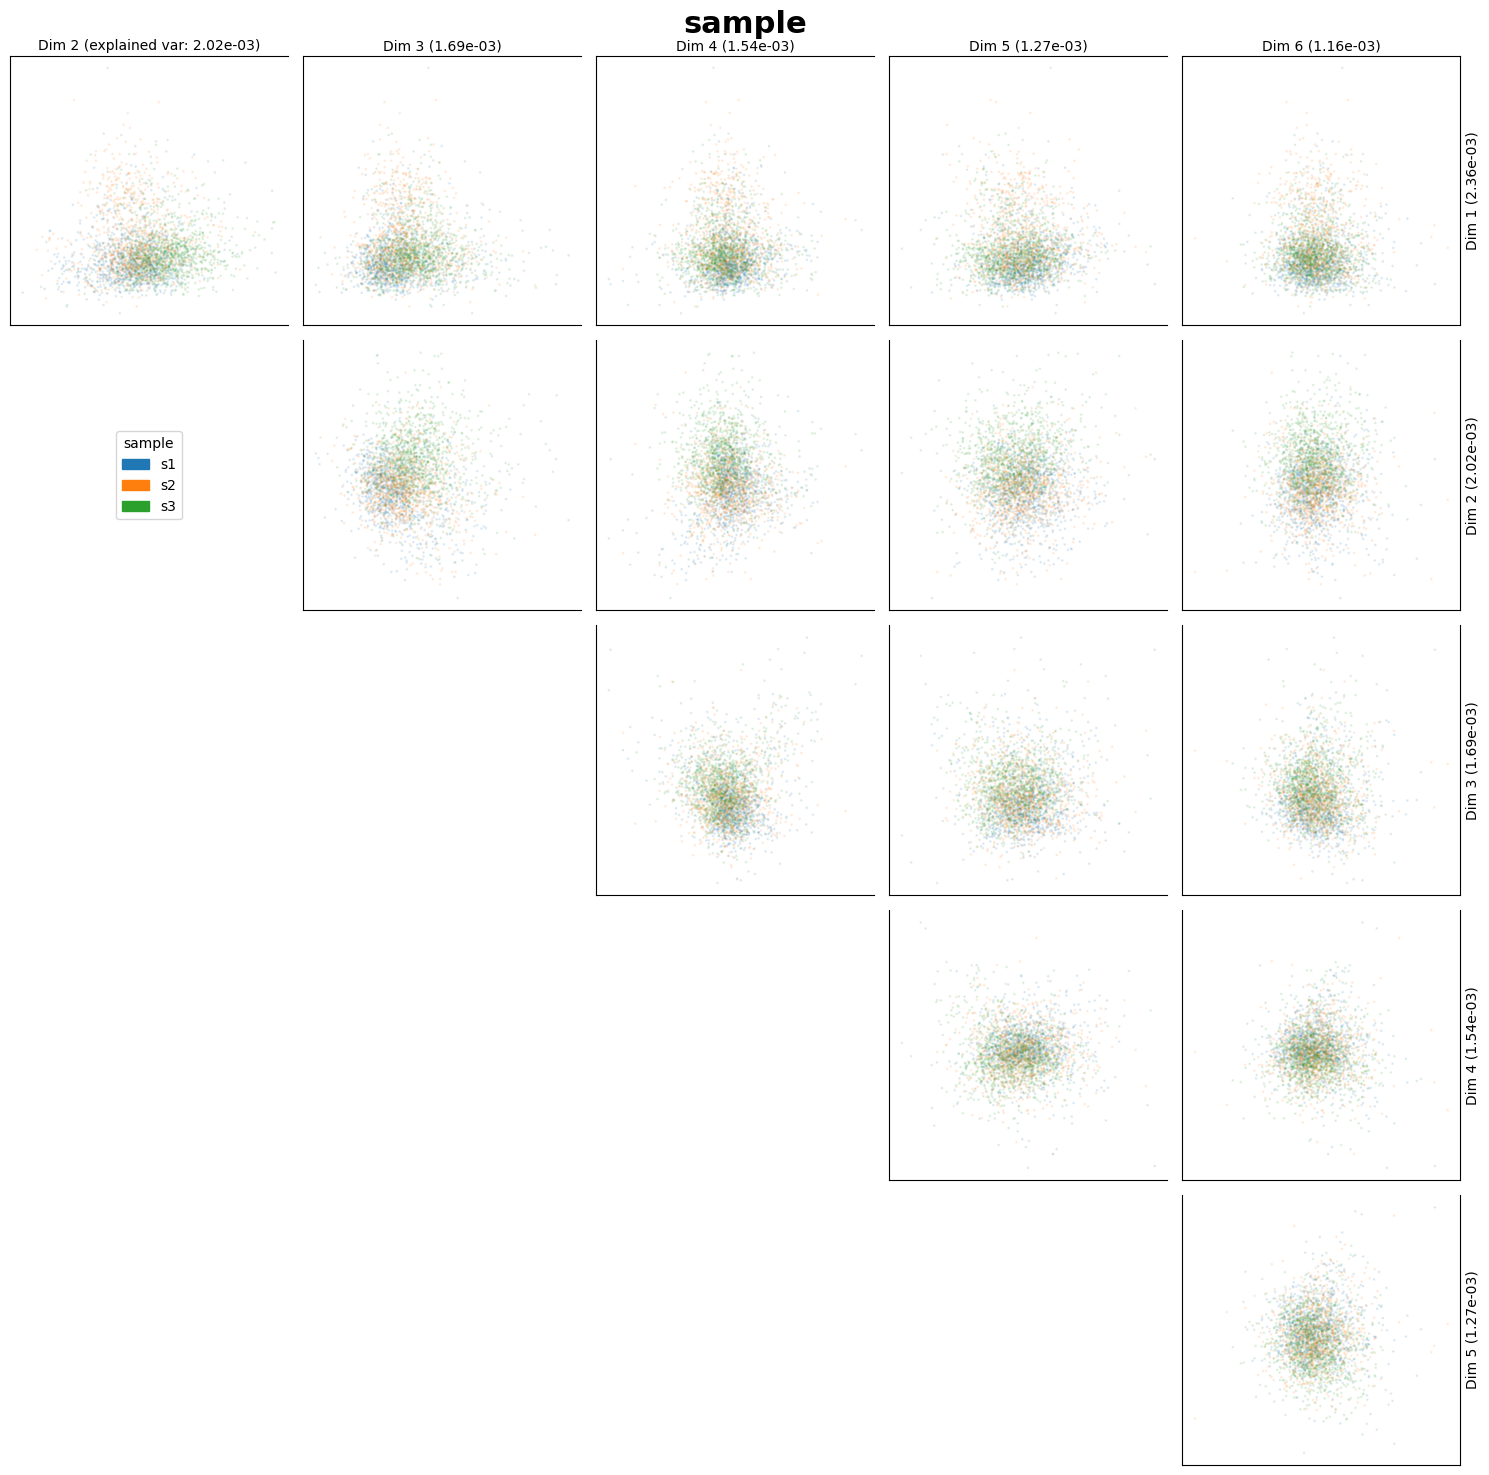

In [25]:
fig_ax_list = st.pl.dim_red(
    adata, 
    columns=["sample"],
    subset_size=1000,
)
plt.show()

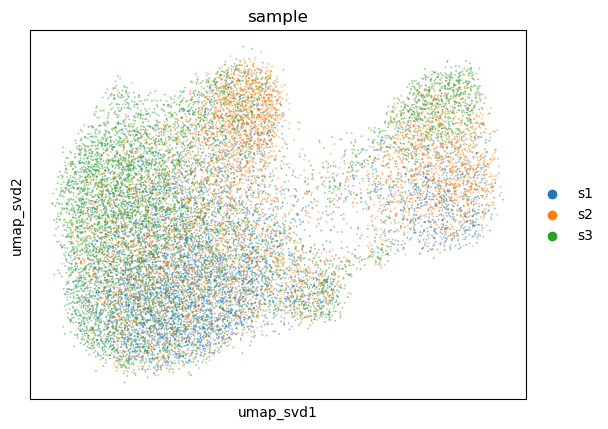

In [26]:
sc.pp.neighbors(
    adata,
    use_rep="X_svd",
    key_added="neighbors_svd",
)

sc.tl.umap(
    adata,
    neighbors_key="neighbors_svd",
    key_added="umap_svd",
)

sc.pl.embedding(
    adata,
    basis="umap_svd",
    color="sample",
    alpha=0.5,
)

# 04 - Clustering

In [27]:
st.pp.knn_count_smoothing(
    adata,
    neighbors_key="neighbors_svd",
)

KNN_binary_mean layer set as adata.X


In [28]:
markerdict = {
    "T_cells": [
        "CD3D", "TRBC1","IL7R", "CD8B",
    ],
    "B_cells": [
        "MS4A1", "CD79A", "CD79B", "CD37"
    ],
    "NK_cells": [
        "NKG7", "GNLY", "KLRD1", "FCGR3A"
    ],
    "Monocytes_Macrophages": [
        "LYZ", "S100A8", "CTSD", "CD14",
    ],
}

T_cells


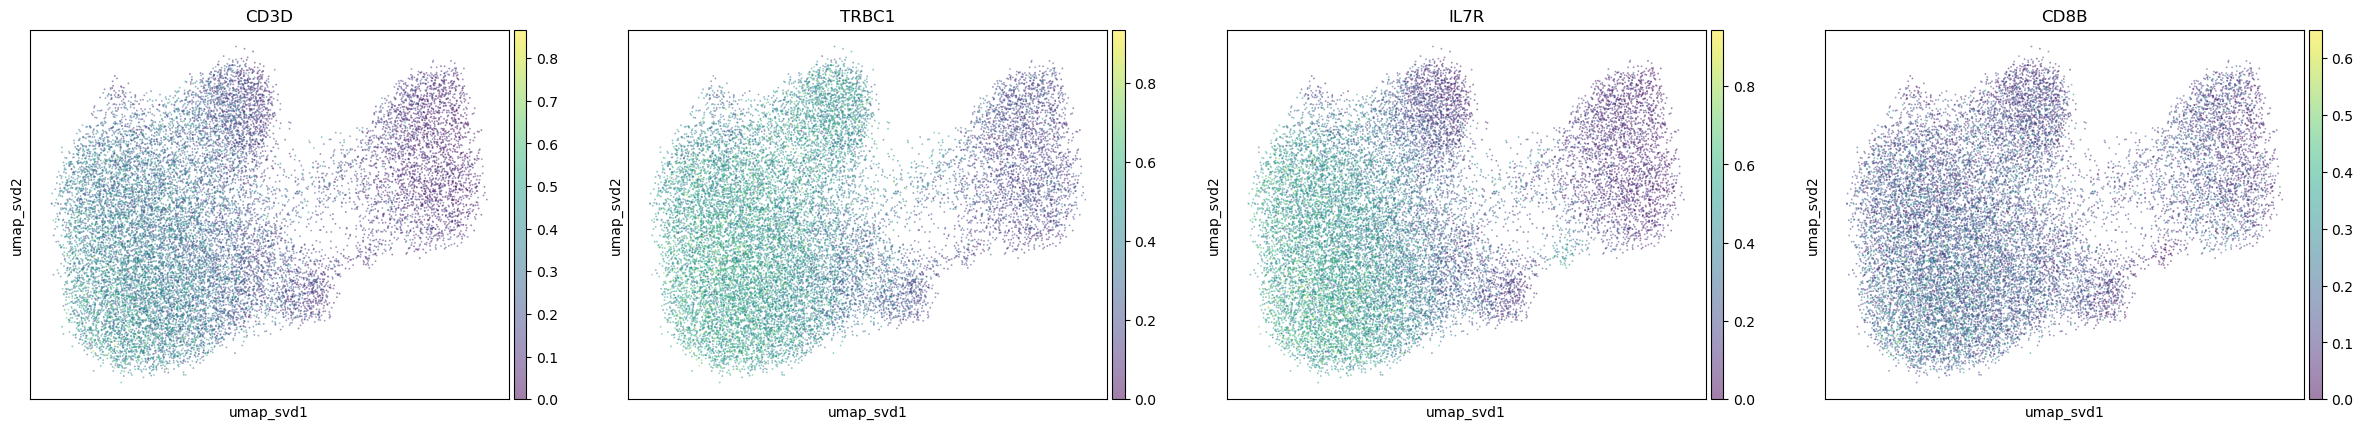

B_cells


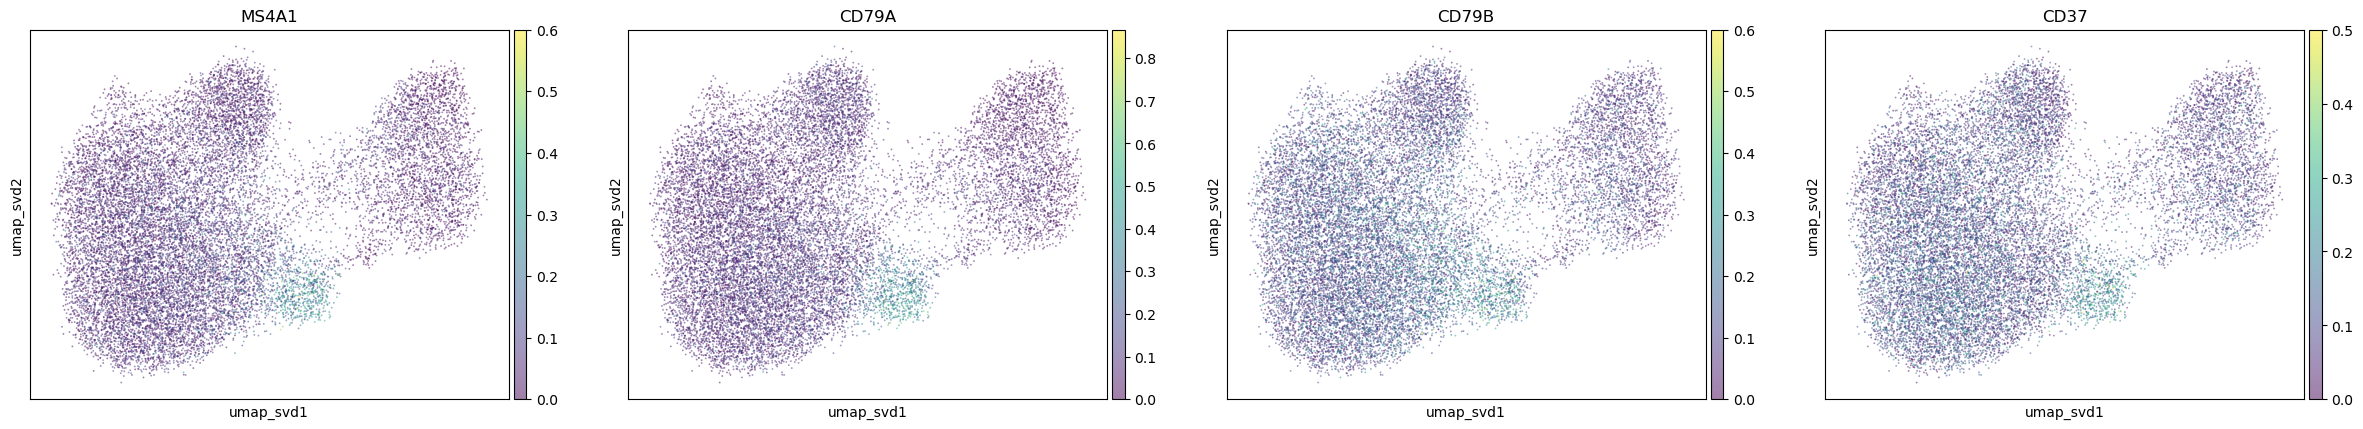

NK_cells


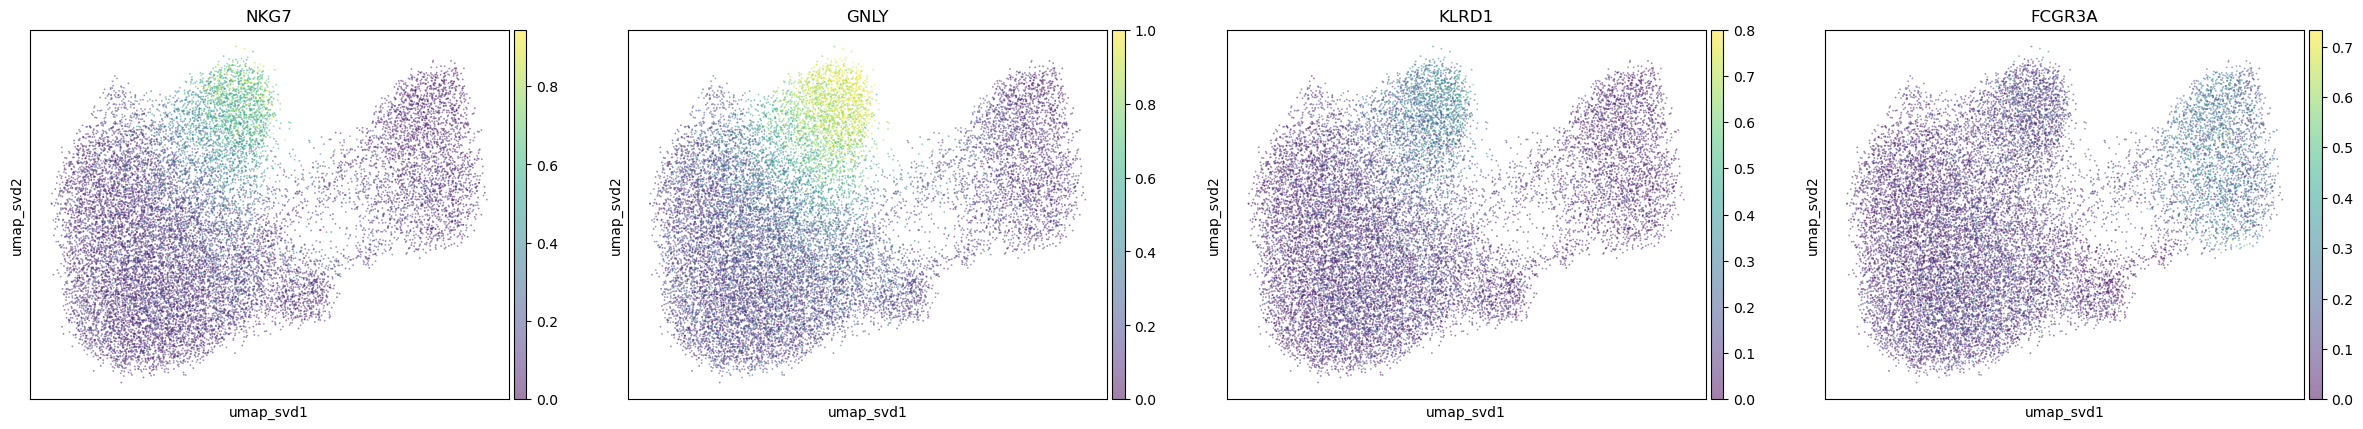

Monocytes_Macrophages


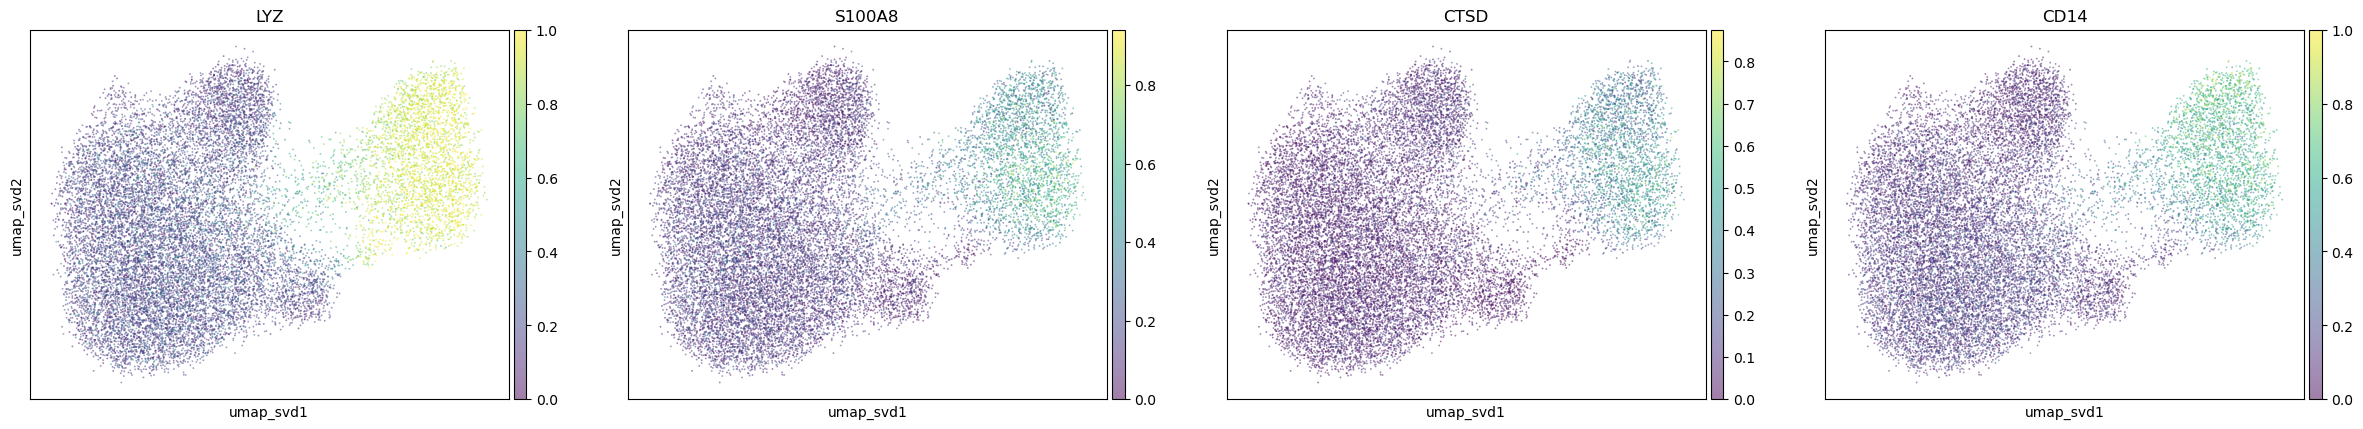

In [29]:
for ctype, markers in markerdict.items():
    print(ctype)
    sc.pl.embedding(
        adata,
        basis="umap_svd",
        color=markers,
        layer="KNN_binary_mean",
        ncols=4,
        alpha=0.5,
    )

In [30]:
res = 0.8
sc.tl.leiden(
    adata,
    resolution=res,
    neighbors_key="neighbors_svd",
    key_added=f"leiden_res_{res:.2f}",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=42,
)

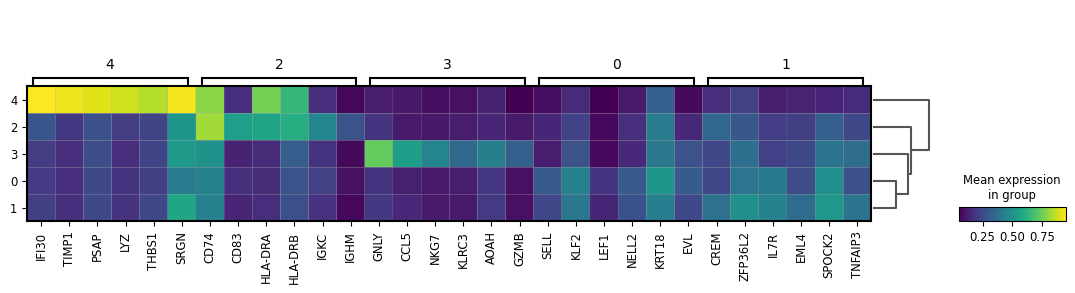

In [31]:
sc.tl.rank_genes_groups(adata, f"leiden_res_{res:.2f}", n_genes=6, layer="binary")
sc.tl.dendrogram(adata, f"leiden_res_{res:.2f}", use_rep="X_svd")
sc.pl.rank_genes_groups_matrixplot(
    adata,
    n_genes=6,
)

In [32]:
cluster2ctype = {
    "0": "T_cells",
    "1": "T_cells", 
    "2": "B_cells",
    "3": "NK_cells",
    "4": "Myeloid_cells",
}
adata.obs["celltype_lvl1"] = adata.obs[f"leiden_res_{res:.2f}"].astype(str).replace(cluster2ctype).astype("category")

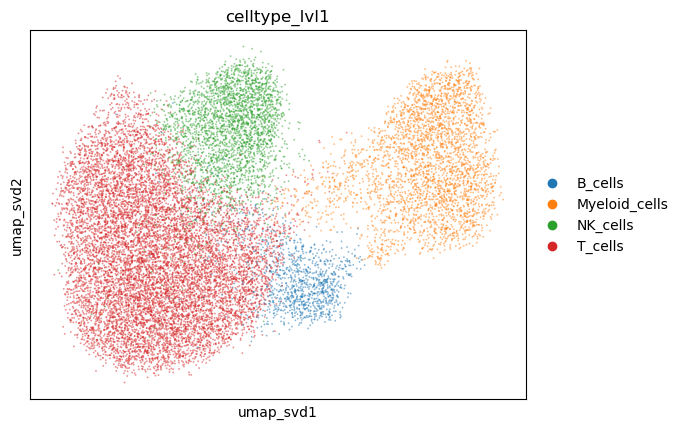

In [33]:
sc.pl.embedding(
    adata,
    basis="umap_svd",
    color="celltype_lvl1",
    alpha=0.5,
)

# 05 - Differential expression analysis

In [34]:
st.pp.combine_obs_columns(adata, ["sample", "celltype_lvl1"], "sample_celltype")
adata.obs["sample_celltype"].value_counts().head()

sample_celltype
s1_T_cells          3945
s3_T_cells          3856
s2_T_cells          2398
s2_NK_cells         1508
s2_Myeloid_cells    1389
Name: count, dtype: int64

## 05a - using detection rates & pbGLM

In [35]:
det_rate_df = st.pp.detection_rates(adata, "sample_celltype")
det_rate_df

,s1_T_cells,s3_T_cells,s2_T_cells,s2_NK_cells,s2_Myeloid_cells,s3_Myeloid_cells,s1_Myeloid_cells,s3_NK_cells,s1_NK_cells,s3_B_cells,s2_B_cells,s1_B_cells
A1BG,0.162369,0.187489,0.193752,0.175967,0.240527,0.234801,0.198269,0.160006,0.157801,0.197007,0.164606,0.209913
A2M,0.022407,0.017345,0.019525,0.022722,0.018959,0.014675,0.022511,0.014198,0.023945,0.027521,0.022792,0.019565
AAAS,0.047622,0.045487,0.056549,0.038122,0.043759,0.036688,0.038335,0.046920,0.046777,0.050527,0.059748,0.052951
AAK1,0.075473,0.077352,0.080821,0.069040,0.049507,0.056604,0.066063,0.081161,0.077190,0.052832,0.043505,0.028372
AAMP,0.043906,0.039657,0.053000,0.033806,0.046951,0.051363,0.067872,0.041222,0.048214,0.050527,0.052773,0.057478
...,...,...,...,...,...,...,...,...,...,...,...,...
ZSWIM6,0.025698,0.020824,0.024430,0.022107,0.046312,0.039832,0.040992,0.021304,0.025363,0.025224,0.011367,0.026164
ZWINT,0.032313,0.033835,0.026886,0.030725,0.018325,0.032495,0.026886,0.025569,0.028204,0.032117,0.031974,0.017374
ZYG11B,0.060825,0.052027,0.060816,0.059129,0.066164,0.062893,0.055257,0.049769,0.066995,0.064363,0.064411,0.041713
ZYX,0.064964,0.087243,0.071871,0.066561,0.136205,0.200210,0.142432,0.096888,0.064093,0.082848,0.036579,0.062023


In [36]:
%%time
results_df1 = st.tl.binomial_glm(
    det_rate_df, 
    adata, 
    column="sample_celltype", 
    test_condition="NK_cells", 
    reference_condition="Myeloid_cells", 
    condition_column="celltype_lvl1",
)
results_df1

CPU times: user 24.7 s, sys: 104 ms, total: 24.8 s
Wall time: 24.8 s


,beta,se,odds_ratio,pval,perfect_separation,error,padj,-log10(padj),log2(odds_ratio)
gene,,,,,,,,,
IFI30,-4.283172,0.086167,0.013799,0.000000e+00,False,None,0.000000e+00,9.0,-6.179311
TIMP1,-4.002432,0.080421,0.018271,0.000000e+00,False,None,0.000000e+00,9.0,-5.774289
LYZ,-3.530694,0.075833,0.029285,0.000000e+00,False,None,0.000000e+00,9.0,-5.093715
PSAP,-3.215753,0.069883,0.040125,0.000000e+00,False,None,0.000000e+00,9.0,-4.639351
THBS1,-3.048667,0.068679,0.047422,0.000000e+00,False,None,0.000000e+00,9.0,-4.398297
...,...,...,...,...,...,...,...,...,...
CD247,2.007373,0.076483,7.443736,7.948598e-152,False,None,1.224785e-149,9.0,2.896027
GZMB,2.022189,0.097241,7.554842,4.733488e-96,False,None,4.065368e-94,9.0,2.917401
NKG7,2.183938,0.080648,8.881211,1.692050e-161,False,None,2.954883e-159,9.0,3.150756


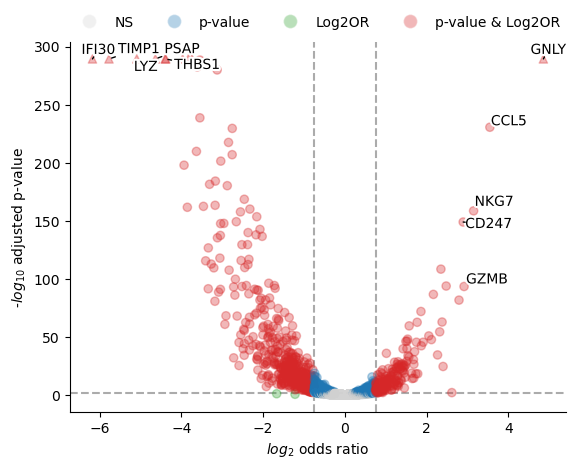

In [37]:
fig, ax = st.pl.binomial_glm_volcano(results_df1)
plt.show()

## 05b - using pyDESeq2

In [38]:
counts = st.pp.pseudobulk(adata, "sample_celltype") 
counts

,s1_T_cells,s1_Myeloid_cells,s1_B_cells,s1_NK_cells,s2_T_cells,s2_Myeloid_cells,s2_NK_cells,s2_B_cells,s3_T_cells,s3_Myeloid_cells,s3_B_cells,s3_NK_cells
A1BG,1073,257,113,129,640,445,344,85,926,262,92,128
A2M,136,27,9,17,58,31,37,10,78,15,12,11
AAAS,293,48,26,36,166,70,65,27,203,37,23,34
AAK1,468,83,15,62,244,81,122,21,353,56,25,60
AAMP,269,80,28,37,164,80,58,25,174,50,23,30
...,...,...,...,...,...,...,...,...,...,...,...,...
ZSWIM6,155,49,12,18,73,74,38,5,92,38,12,16
ZWINT,201,31,9,20,80,30,51,15,154,31,14,18
ZYG11B,387,66,19,51,182,111,100,29,233,63,28,36
ZYX,411,184,28,49,220,251,118,16,406,222,39,72


In [39]:
%%time
results_df2 = st.tl.pydeseq2(
    counts, 
    adata, 
    column="sample_celltype", 
    test_condition="NK_cells", 
    reference_condition="Myeloid_cells", 
    condition_column="celltype_lvl1",
)
results_df2

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 0.58 seconds.

Fitting dispersion trend curve...
/home/siebrenf/miniconda3/envs/stampede/lib/python3.14/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.58 seconds.

Fitting LFCs...
... done in 0.54 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: celltype_lvl1 NK_cells vs Myeloid_cells
          baseMean  log2FoldChange     lfcSE      stat        pvalue      padj
A1BG    263.666305       -0.434354  0.151344 -2.869982  4.104947e-03  0.022103
A2M      25.305038        0.095571  0.282326  0.338513  7.349766e-01  0.873526
AAAS     59.149834        0.098362  0.209311  0.469932  6.384039e-01  0.811281
AAK1     81.627088        0.429604  0.180553  2.379381  1.734176e-02  0.072272
AAMP     61.919492       -0.448250  0.226471 -1.979283  4.778412e-02  0.155945
...            ...             ...       ...       ...           ...       ...
ZSWIM6   34.025985       -0.881612  0.241566 -3.649567  2.626826e-04  0.001980
ZWINT    34.819251        0.186154  0.260609  0.714304  4.750392e-01  0.696928
ZYG11B   73.548928       -0.083079  0.191312 -0.434258  6.641009e-01  0.830909
ZYX     123.026529       -1.187017  0.242326 -4.898432  9.660429e-07  0.000011
ZZZ3     66.493282        0.139465  0.197241  0.70707

... done in 0.44 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,263.666305,-0.434354,0.151344,-2.869982,4.104947e-03,0.022103
A2M,25.305038,0.095571,0.282326,0.338513,7.349766e-01,0.873526
AAAS,59.149834,0.098362,0.209311,0.469932,6.384039e-01,0.811281
AAK1,81.627088,0.429604,0.180553,2.379381,1.734176e-02,0.072272
AAMP,61.919492,-0.448250,0.226471,-1.979283,4.778412e-02,0.155945
...,...,...,...,...,...,...
ZSWIM6,34.025985,-0.881612,0.241566,-3.649567,2.626826e-04,0.001980
ZWINT,34.819251,0.186154,0.260609,0.714304,4.750392e-01,0.696928
ZYG11B,73.548928,-0.083079,0.191312,-0.434258,6.641009e-01,0.830909
ZYX,123.026529,-1.187017,0.242326,-4.898432,9.660429e-07,0.000011


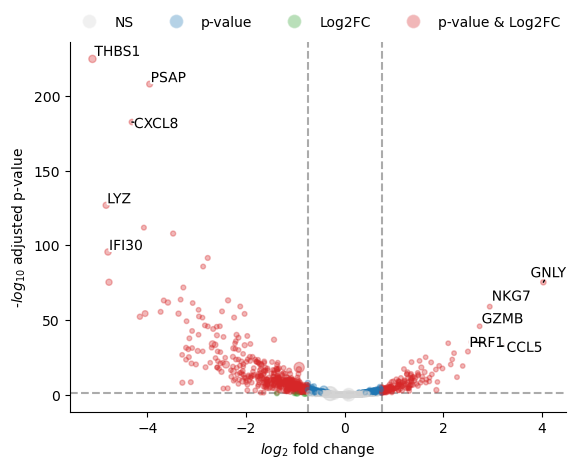

In [40]:
fig, axs = st.pl.pydeseq2_volcano(results_df2)
plt.show()